In [1]:
import pandas as pd
import numpy as np
import ast
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

# ── Load dataset ──────────────────────────────────────────────
CSV_PATH = 'IT Support Ticket Data.csv'  
df = pd.read_csv(CSV_PATH)
df = df.rename(columns={
    'Body': 'body',
    'Department': 'department',
    'Priority': 'priority',
    'Tags': 'tags'
})
df = df.dropna(subset=['body', 'department', 'priority', 'tags'])
df['body'] = df['body'].astype(str).str.strip()

print(f'Dataset shape : {df.shape}')
df.head(3)

C:\Users\ADMIN\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Dataset shape : (29650, 5)


,Unnamed: 0,body,department,priority,tags
0,0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."


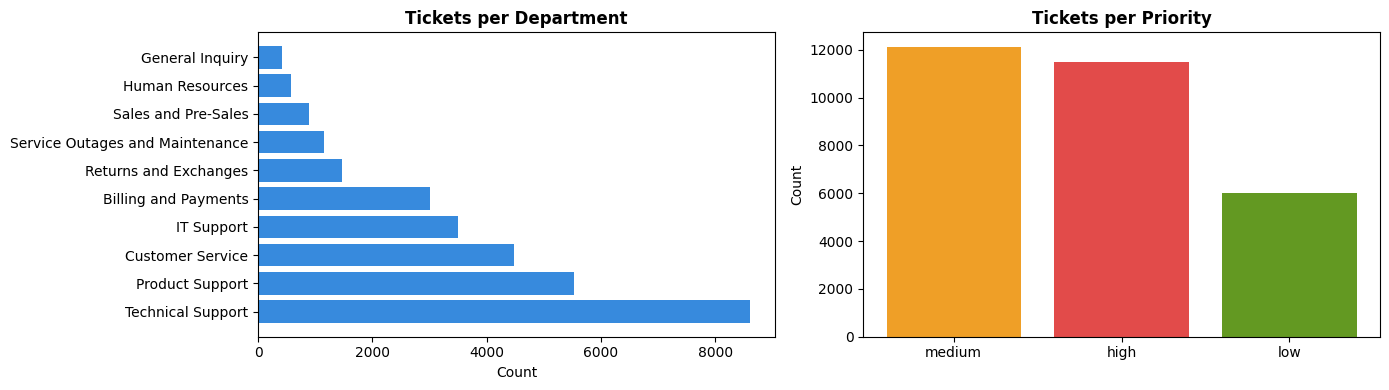

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dept_counts = df['department'].value_counts()
axes[0].barh(dept_counts.index, dept_counts.values, color='#378ADD')
axes[0].set_title('Tickets per Department', fontweight='bold')
axes[0].set_xlabel('Count')

prio_counts = df['priority'].value_counts()
colors = {'high': '#E24B4A', 'medium': '#EF9F27', 'low': '#639922'}
axes[1].bar(prio_counts.index, prio_counts.values,
            color=[colors.get(p, '#888') for p in prio_counts.index])
axes[1].set_title('Tickets per Priority', fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

# ── Parse tags from string representation of Python list ──────
def parse_tags(tag_str):
    try:
        return [t.strip() for t in ast.literal_eval(tag_str) if t.strip()]
    except Exception:
        return []

df['tags_list'] = df['tags'].apply(parse_tags)

# Keep only top-20 most frequent tags (avoids sparse matrix)
all_tags = [t for sublist in df['tags_list'] for t in sublist]
TOP_TAGS = 20
top_tag_set = set([t for t, _ in Counter(all_tags).most_common(TOP_TAGS)])
df['tags_list'] = df['tags_list'].apply(lambda l: [t for t in l if t in top_tag_set])
df = df[df['tags_list'].map(len) > 0].reset_index(drop=True)

print(f'Rows after filtering : {len(df):,}')
print(f'Top {TOP_TAGS} tags   : {sorted(top_tag_set)}')

Rows after filtering : 27,916
Top 20 tags   : ['Billing', 'Bug', 'Crash', 'Disruption', 'Documentation', 'Feature', 'Feedback', 'Guidance', 'IT', 'Integration', 'Network', 'Outage', 'Performance', 'Product', 'Recovery', 'Resolution', 'Sales', 'Security', 'Tech Support', 'Technical']


In [4]:
X      = df['body']
y_dept = df['department']
y_prio = df['priority']
y_tags = df['tags_list']

X_train, X_test, \
yd_train, yd_test, \
yp_train, yp_test, \
yt_train, yt_test = train_test_split(
    X, y_dept, y_prio, y_tags,
    test_size=0.2, random_state=42, stratify=y_dept
)

print(f'Train : {len(X_train):,}  |  Test : {len(X_test):,}')

Train : 22,332  |  Test : 5,584


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Shared vectorizer used by all 3 models
tfidf = TfidfVectorizer(
    max_features=15_000,
    ngram_range=(1, 2),      # unigrams + bigrams
    sublinear_tf=True,       # log(1+tf) — dampens high-freq terms
    stop_words='english',
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Vocabulary size : {len(tfidf.vocabulary_):,} features')
print(f'Matrix shape    : {X_train_tfidf.shape}')

Vocabulary size : 15,000 features
Matrix shape    : (22332, 15000)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

dept_model = LogisticRegression(
    C=5.0, max_iter=1000,
    solver='lbfgs', random_state=42, n_jobs=-1
)
dept_model.fit(X_train_tfidf, yd_train)
yd_pred = dept_model.predict(X_test_tfidf)

dept_acc = accuracy_score(yd_test, yd_pred)
dept_f1  = f1_score(yd_test, yd_pred, average='weighted')

print(f'Accuracy : {dept_acc:.4f}  ({dept_acc*100:.2f}%)')
print(f'F1-Score : {dept_f1:.4f}\n')
print(classification_report(yd_test, yd_pred, zero_division=0))

Accuracy : 0.6698  (66.98%)
F1-Score : 0.6674

                                 precision    recall  f1-score   support

           Billing and Payments       0.89      0.81      0.85       575
               Customer Service       0.60      0.64      0.62       838
                General Inquiry       0.97      0.41      0.57        79
                Human Resources       0.97      0.52      0.68       107
                     IT Support       0.67      0.54      0.60       659
                Product Support       0.61      0.64      0.63      1050
          Returns and Exchanges       0.81      0.50      0.62       275
            Sales and Pre-Sales       0.76      0.38      0.50       164
Service Outages and Maintenance       0.85      0.64      0.73       219
              Technical Support       0.63      0.79      0.70      1618

                       accuracy                           0.67      5584
                      macro avg       0.78      0.59      0.65      5584
  

In [7]:
prio_model = LogisticRegression(
    C=5.0, max_iter=1000,
    solver='lbfgs', random_state=42, n_jobs=-1
)
prio_model.fit(X_train_tfidf, yp_train)
yp_pred = prio_model.predict(X_test_tfidf)

prio_acc = accuracy_score(yp_test, yp_pred)
prio_f1  = f1_score(yp_test, yp_pred, average='weighted')

print(f'Accuracy : {prio_acc:.4f}  ({prio_acc*100:.2f}%)')
print(f'F1-Score : {prio_f1:.4f}\n')
print(classification_report(yp_test, yp_pred, zero_division=0))

Accuracy : 0.7111  (71.11%)
F1-Score : 0.7094

              precision    recall  f1-score   support

        high       0.72      0.75      0.74      2165
         low       0.72      0.57      0.64      1132
      medium       0.70      0.74      0.72      2287

    accuracy                           0.71      5584
   macro avg       0.71      0.69      0.70      5584
weighted avg       0.71      0.71      0.71      5584



In [8]:
from sklearn.multiclass import OneVsRestClassifier

mlb = MultiLabelBinarizer()
yt_train_bin = mlb.fit_transform(yt_train)
yt_test_bin  = mlb.transform(yt_test)

tag_model = OneVsRestClassifier(
    LogisticRegression(C=3.0, max_iter=500, solver='lbfgs', random_state=42),
    n_jobs=-1
)
tag_model.fit(X_train_tfidf, yt_train_bin)
yt_pred_bin = tag_model.predict(X_test_tfidf)

tag_f1_micro = f1_score(yt_test_bin, yt_pred_bin, average='micro')
tag_f1_macro = f1_score(yt_test_bin, yt_pred_bin, average='macro')

print(f'F1-Micro : {tag_f1_micro:.4f}')
print(f'F1-Macro : {tag_f1_macro:.4f}')
print(f'Tags     : {mlb.classes_.tolist()}')

F1-Micro : 0.7931
F1-Macro : 0.7405
Tags     : ['Billing', 'Bug', 'Crash', 'Disruption', 'Documentation', 'Feature', 'Feedback', 'Guidance', 'IT', 'Integration', 'Network', 'Outage', 'Performance', 'Product', 'Recovery', 'Resolution', 'Sales', 'Security', 'Tech Support', 'Technical']


In [9]:
MODEL_PATH = 'models.pkl'

model_bundle = {
    'tfidf':      tfidf,
    'dept_model': dept_model,
    'prio_model': prio_model,
    'tag_model':  tag_model,
    'mlb':        mlb,
    'metrics': {
        'dept_acc':     round(dept_acc * 100, 2),
        'dept_f1':      round(dept_f1, 4),
        'prio_acc':     round(prio_acc * 100, 2),
        'prio_f1':      round(prio_f1, 4),
        'tag_f1_micro': round(tag_f1_micro, 4),
        'tag_f1_macro': round(tag_f1_macro, 4),
        'n_rows':       len(df),
        'n_departments': df['department'].nunique(),
        'departments':  df['department'].unique().tolist(),
    }
}

In [10]:
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f'✅ Models saved to  →  {MODEL_PATH}')
print(f'   Keys stored      : {list(model_bundle.keys())}')

✅ Models saved to  →  models.pkl
   Keys stored      : ['tfidf', 'dept_model', 'prio_model', 'tag_model', 'mlb', 'metrics']


In [11]:
def predict_ticket(body_text, top_k_tags=5):
    """
    Predict department, priority, and tags from ticket body text.
    Returns a dict with predictions and confidence scores.
    """
    vec = tfidf.transform([body_text])

    # Department
    dept       = dept_model.predict(vec)[0]
    dept_proba = dict(zip(dept_model.classes_, dept_model.predict_proba(vec)[0]))
    top_depts  = sorted(dept_proba.items(), key=lambda x: -x[1])[:3]

    # Priority
    prio       = prio_model.predict(vec)[0]
    prio_proba = dict(zip(prio_model.classes_, prio_model.predict_proba(vec)[0]))

    # Tags
    tag_proba  = tag_model.predict_proba(vec)[0]
    top_idx    = np.argsort(tag_proba)[::-1][:top_k_tags]
    pred_tags  = [mlb.classes_[i] for i in top_idx if tag_proba[i] > 0.2]

    return {
        'department':      dept,
        'dept_confidence': round(dept_proba.get(dept, 0) * 100, 1),
        'top_departments': [(d, round(p*100, 1)) for d, p in top_depts],
        'priority':        prio,
        'prio_confidence': round(prio_proba.get(prio, 0) * 100, 1),
        'priority_probs':  {k: round(v*100, 1) for k, v in prio_proba.items()},
        'predicted_tags':  pred_tags,
    }


# ── Demo predictions ─────────────────────────────────────────
sample_tickets = [
    "Our entire network is down. No one in the office can connect to the internet. VPN is failing too. Critical business disruption.",
    "My invoice shows duplicate charges for last month. I was charged twice. Need an urgent refund.",
    "The app keeps crashing every time I export a PDF report. Error code 0x8004E. Tried reinstalling.",
    "Looking for information on enterprise pricing and bulk licences for 200 employees.",
]

for i, ticket in enumerate(sample_tickets, 1):
    r = predict_ticket(ticket)
    print(f'\n─── Ticket #{i} ───────────────────────────────────────')
    print(f'Body     : {ticket[:80]}...')
    print(f'Dept     : {r["department"]} ({r["dept_confidence"]}%)')
    print(f'Priority : {r["priority"].upper()} ({r["prio_confidence"]}%)')
    print(f'Tags     : {", ".join(r["predicted_tags"])}')


─── Ticket #1 ───────────────────────────────────────
Body     : Our entire network is down. No one in the office can connect to the internet. VP...
Dept     : IT Support (65.9%)
Priority : HIGH (65.9%)
Tags     : Network, Disruption, IT, Tech Support, Performance

─── Ticket #2 ───────────────────────────────────────
Body     : My invoice shows duplicate charges for last month. I was charged twice. Need an ...
Dept     : Billing and Payments (94.9%)
Priority : HIGH (54.8%)
Tags     : Billing, Disruption

─── Ticket #3 ───────────────────────────────────────
Body     : The app keeps crashing every time I export a PDF report. Error code 0x8004E. Tri...
Dept     : Technical Support (45.0%)
Priority : MEDIUM (91.4%)
Tags     : Bug, Performance, Crash, Tech Support, IT

─── Ticket #4 ───────────────────────────────────────
Body     : Looking for information on enterprise pricing and bulk licences for 200 employee...
Dept     : Billing and Payments (57.1%)
Priority : MEDIUM (87.8%)
Tags   

In [12]:
summary = pd.DataFrame({
    'Model':    ['Department Routing', 'Priority Prediction', 'Tag Prediction'],
    'Type':     ['Multiclass LR', 'Multiclass LR', 'Multi-label OvR LR'],
    'Accuracy': [f'{dept_acc*100:.2f}%', f'{prio_acc*100:.2f}%', '—'],
    'F1-Score': [f'{dept_f1:.4f}',  f'{prio_f1:.4f}',  f'{tag_f1_micro:.4f} (micro)'],
})

summary.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#1a1a2e'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('padding', '8px 16px')]},
]).hide(axis='index')

Model,Type,Accuracy,F1-Score
Department Routing,Multiclass LR,66.98%,0.6674
Priority Prediction,Multiclass LR,71.11%,0.7094
Tag Prediction,Multi-label OvR LR,—,0.7931 (micro)
